# Dimensionality Reduction

## Objectives

This notebook evaluates dimensionality-reduction techniques on the prepared
analytical feature matrix produced during the Data Preparation phase.

The objectives are to:

1. establish the dimensionality of the prepared analytical feature space;
2. evaluate Principal Component Analysis (PCA) as the primary dimensionality-
   reduction technique;
3. examine explained variance and principal-component structure;
4. determine a defensible reduced representation for subsequent clustering;
5. evaluate Multidimensional Scaling (MDS) as a complementary representation;
6. evaluate Locally Linear Embedding (LLE) only if its use is justified by the
   characteristics of the prepared feature space.

The prepared analytical matrix is loaded from `data/processed/` so that this
notebook continues directly from the decisions established in Notebook 02.

## Analytical Context

Notebook 02 completed the data-cleaning, feature-engineering, imputation, and
categorical-encoding stages.

The resulting analytical matrix is the input for this notebook. No additional
data cleaning, feature engineering, or categorical encoding is performed here.

Dimensionality reduction is evaluated because the prepared representation
contains substantially more features than the original survey variables. A
lower-dimensional representation may make the structure of the observations
more tractable for subsequent clustering while retaining the dominant patterns
in the prepared feature space.

In [10]:
# Import the necessary libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

pd.set_option("display.max_columns", None)

In [2]:
# Load the canonical analytical matrix generated by Notebook 02.
processed_path = Path("../data/processed/mental_health_prepared.csv")

X_encoded = pd.read_csv(
    processed_path,
    index_col=0,
)

print(
    "Prepared analytical matrix loaded: "
    f"{X_encoded.shape[0]:,} observations x "
    f"{X_encoded.shape[1]} features."
)

Prepared analytical matrix loaded: 1,433 observations x 495 features.


In [3]:
# Verify that the downstream analytical input is numerical and complete.
if X_encoded.isna().any().any():
    raise ValueError(
        "The prepared analytical matrix contains missing values."
    )

if not all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X_encoded.dtypes
):
    raise TypeError(
        "The prepared analytical matrix must contain only numerical features."
    )

print("Prepared analytical matrix validation passed.")

Prepared analytical matrix validation passed.


## Prepared Feature Space

The processed matrix contains the encoded numerical representation that will be
used for dimensionality-reduction experiments.

The dimensionality is recorded here as the starting point for assessing the
benefit of reducing the feature space.

In [4]:
print(
    f"Starting dimensionality: {X_encoded.shape[1]} features "
    f"for {X_encoded.shape[0]:,} observations."
)

Starting dimensionality: 495 features for 1,433 observations.


## Principal Component Analysis

PCA is evaluated first because it provides a linear transformation of the
prepared feature space into orthogonal principal components ordered by the
amount of variance they explain.

The initial PCA fit retains all possible components. This allows the explained
variance structure to be examined before selecting a reduced representation.

In [5]:
# Fit PCA across the complete prepared feature space to quantify its variance structure.
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_encoded)

explained_variance = pd.DataFrame(
    {
        "component": range(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": pca_full.explained_variance_ratio_.cumsum(),
    }
)

explained_variance.head()

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.661342,0.661342
1,2,0.047187,0.708528
2,3,0.021863,0.730392
3,4,0.018061,0.748452
4,5,0.013933,0.762385


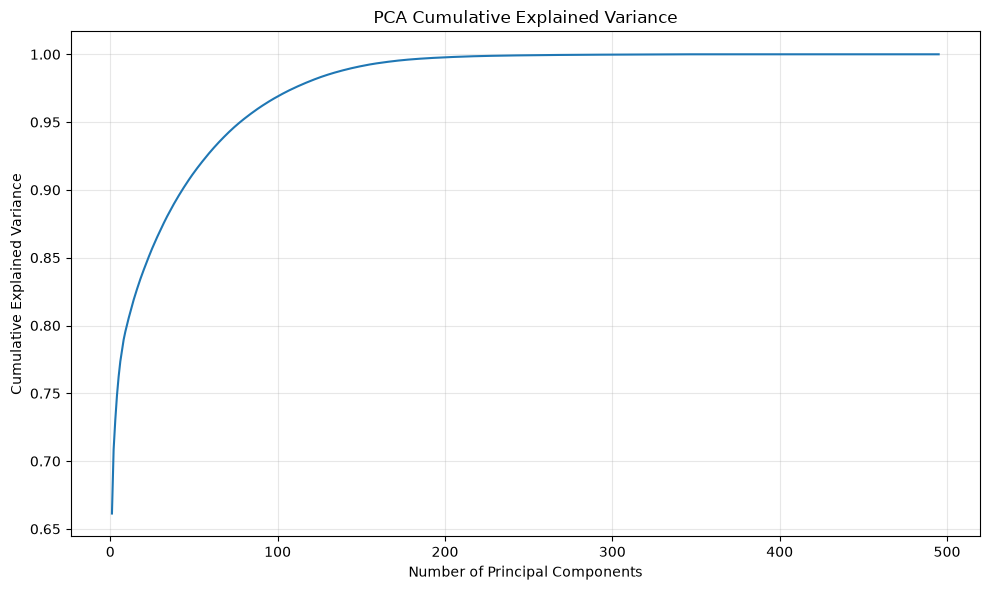

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_explained_variance",
    ax=ax,
)

ax.set(
    title="PCA Cumulative Explained Variance",
    xlabel="Number of Principal Components",
    ylabel="Cumulative Explained Variance",
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

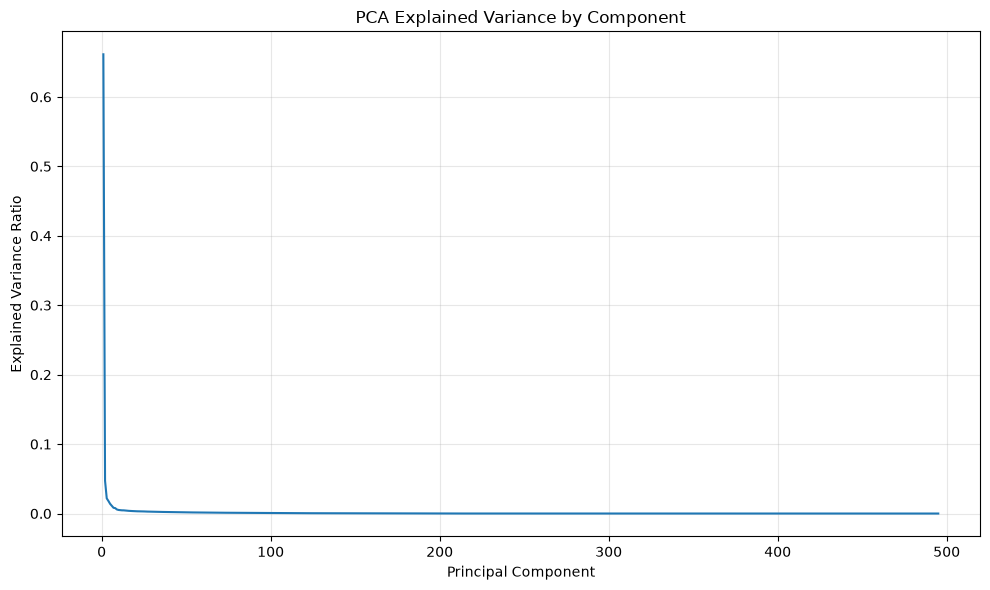

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="explained_variance_ratio",
    ax=ax,
)

ax.set(
    title="PCA Explained Variance by Component",
    xlabel="Principal Component",
    ylabel="Explained Variance Ratio",
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Report the number of components required to reach commonly examined
# cumulative-variance thresholds without treating any threshold as an
# automatic modelling decision.
variance_thresholds = pd.DataFrame(
    {
        "variance_threshold": [0.80, 0.90, 0.95],
        "components_required": [
            (pca_full.explained_variance_ratio_.cumsum() >= threshold).argmax() + 1
            for threshold in [0.80, 0.90, 0.95]
        ],
    }
)

variance_thresholds

,variance_threshold,components_required
0,0.80,10
1,0.90,44
2,0.95,78


### PCA Interpretation

The cumulative explained-variance results indicate how rapidly the prepared
feature space can be represented using fewer dimensions.

The reported thresholds are diagnostic reference points rather than automatic
selection rules. The final PCA representation must also remain appropriate for
the subsequent clustering experiments and their evaluation.

## Principal Component Loadings

The PCA components are examined to identify which prepared features contribute
most strongly to the leading components.

This provides interpretability for the reduced representation and helps assess
whether the dominant components capture meaningful structure in the prepared
survey representation.

In [11]:
pca_components = pd.DataFrame(
    pca_full.components_,
    columns=X_encoded.columns,
    index=[
        f"PC{i}"
        for i in range(1, pca_full.n_components_ + 1)
    ],
)

pca_components.head()

,age__What is your age?,binary__Are you self-employed?,binary__Is your employer primarily a tech company/organization?,binary__Is your primary role within your company related to tech/IT?,binary__Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,binary__Do you have previous employers?,binary__Have you ever sought treatment for a mental health issue from a mental health professional?,binary__work_position__Back-end Developer,binary__work_position__Designer,binary__work_position__Dev Evangelist/Advocate,binary__work_position__DevOps/SysAdmin,binary__work_position__Executive Leadership,binary__work_position__Front-end Developer,binary__work_position__HR,binary__work_position__One-person shop,binary__work_position__Other,binary__work_position__Sales,binary__work_position__Supervisor/Team Lead,binary__work_position__Support,binary__missingindicator_Is your employer primarily a tech company/organization?,binary__missingindicator_Is your primary role within your company related to tech/IT?,binary__missingindicator_Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,categorical__How many employees does your company or organization have?_1-5,categorical__How many employees does your company or organization have?_100-500,categorical__How many employees does your company or organization have?_26-100,categorical__How many employees does your company or organization have?_500-1000,categorical__How many employees does your company or organization have?_6-25,categorical__How many employees does your company or organization have?_Missing,categorical__How many employees does your company or organization have?_More than 1000,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_I don't know,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Missing,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_No,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Not eligible for coverage / N/A,categorical__Does your employer provide mental health benefits as part of healthcare coverage?_Yes,categorical__Do you know the options for mental health care available under your employer-provided coverage?_I am not sure,categorical__Do you know the options for mental health care available under your employer-provided coverage?_Missing,categorical__Do you know the options for mental health care available under your employer-provided coverage?_No,categorical__Do you know the options for mental health care available under your employer-provided coverage?_Yes,"categorical__Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_I don't know","categorical__Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_Missing","categorical__Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_No","categorical__Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_Yes",categorical__Does your employer offer resources to learn more about mental health concerns and options for seeking help?_I don't know,categorical__Does your employer offer resources to learn more about mental health concerns and options for seeking help?_Missing,categorical__Does your employer offer resources to learn more about mental health concerns and options for seeking help?_No,categorical__Does your employer offer resources to learn more about mental health concerns and options for seeking help?_Yes,categorical__Is your anonymity protected if you choose to take advantage of mental health or 

In [12]:
# Identify the features with the largest absolute loading across the first
# five principal components.
top_loadings = (
    pca_components.iloc[:5]
    .T
    .assign(
        max_absolute_loading=lambda data: data.abs().max(axis=1)
    )
    .sort_values("max_absolute_loading", ascending=False)
)

top_loadings.head(20)

,PC1,PC2,PC3,PC4,PC5,max_absolute_loading
age__What is your age?,0.997824,-0.048155,0.022936,-0.017323,0.001682,0.997824
categorical__Have you been diagnosed with a mental health condition by a medical professional?_Yes,0.003973,0.004294,-0.268656,-0.025810,-0.009741,0.268656
categorical__Have you been diagnosed with a mental health condition by a medical professional?_No,-0.003973,-0.004294,0.268656,0.025810,0.009741,0.268656
categorical__Have you had a mental health disorder in the past?_Yes,0.003706,0.004445,-0.256981,-0.016857,-0.012605,0.256981
binary__Have you ever sought treatment for a mental health issue from a mental health professional?,0.004298,0.010869,-0.251700,-0.015730,-0.024887,0.251700
"categorical__If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?_Not applicable to me",-0.004310,-0.008835,0.249104,0.035788,0.018819,0.249104
"categorical__If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?_Not applicable to me",-0.003066,-0.009860,0.239760,0.031568,-0.003131,0.239760
categorical__Do you currently have a mental health disorder?_Yes,-0.000107,0.009360,-0.229465,-0.029343,-0.011549,0.229465
binary__Do you have previous employers?,0.005921,-0.010155,-0.046097,0.224337,0.031228,0.224337
categorical__Would you have been willing to discuss a mental health issue with your direct supervisor(s)?_Missing,-0.005921,0.010155,0.046097,-0.224337,-0.031228,0.224337


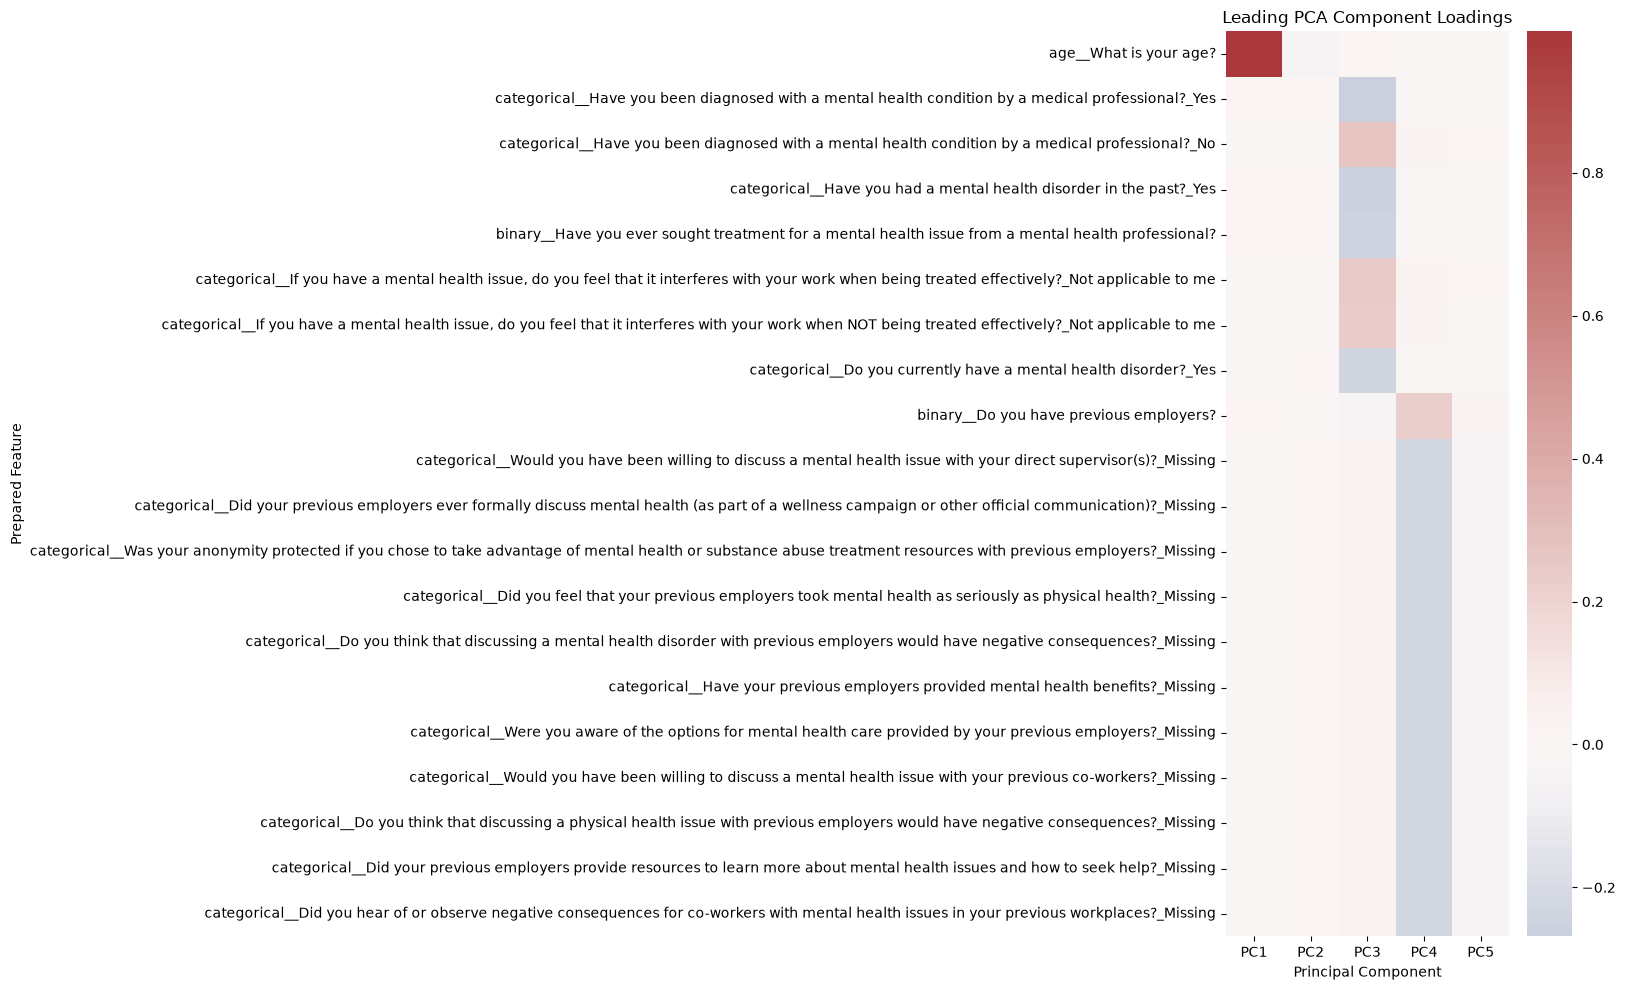

In [18]:
# Display the strongest-loading features for the leading components.
loading_features = top_loadings.head(20).drop(
    columns="max_absolute_loading"
)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    loading_features,
    cmap="vlag",
    center=0,
    ax=ax,
)

ax.set(
    title="Leading PCA Component Loadings",
    xlabel="Principal Component",
    ylabel="Prepared Feature",
)

plt.tight_layout()
plt.show()

In [19]:
# Use the 90% cumulative explained-variance point as an initial reduced
# representation for downstream comparison
pca_component_count = int(
    variance_thresholds.loc[
        variance_thresholds["variance_threshold"] == 0.90,
        "components_required",
    ].iloc[0]
)

pca_reduced = PCA(
    n_components=pca_component_count,
)

X_pca = pd.DataFrame(
    pca_reduced.fit_transform(X_encoded),
    columns=[
        f"PC{i}"
        for i in range(1, pca_component_count + 1)
    ],
    index=X_encoded.index,
)

print(
    "PCA reduced representation: "
    f"{X_pca.shape[0]:,} observations x "
    f"{X_pca.shape[1]} components."
)

print(
    "Cumulative explained variance: "
    f"{pca_reduced.explained_variance_ratio_.sum():.2%}"
)

PCA reduced representation: 1,433 observations x 44 components.
Cumulative explained variance: 90.18%


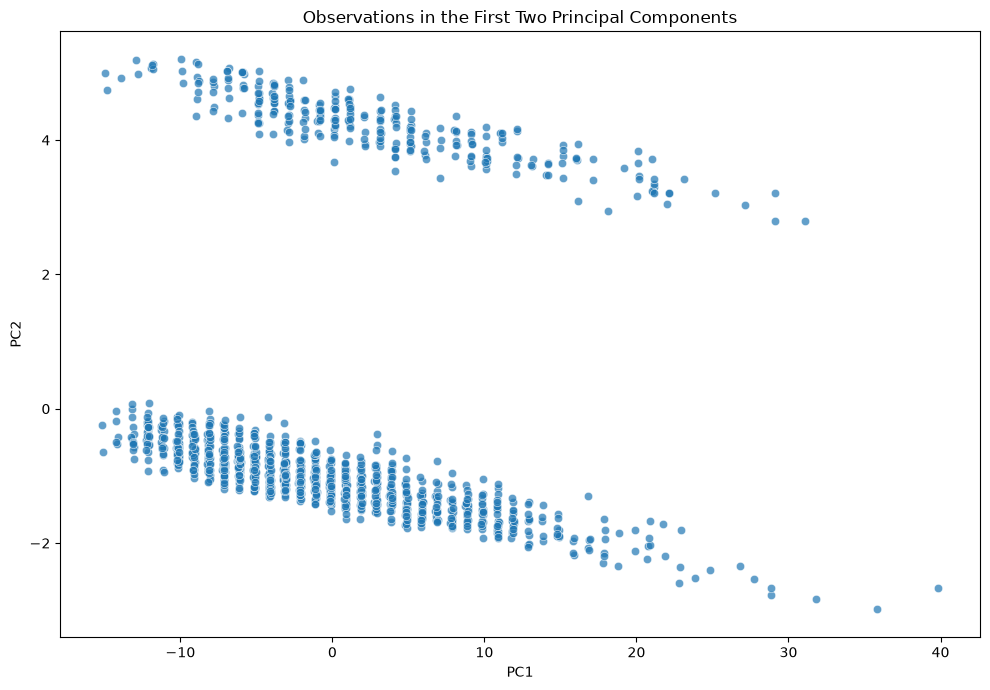

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    x=X_pca.iloc[:, 0],
    y=X_pca.iloc[:, 1],
    alpha=0.7,
    ax=ax,
)

ax.set(
    title="Observations in the First Two Principal Components",
    xlabel="PC1",
    ylabel="PC2",
)

plt.tight_layout()
plt.show()

## Multidimensional Scaling

MDS is evaluated as a complementary dimensionality-reduction approach.

Unlike PCA, which seeks orthogonal directions explaining variance, MDS seeks a
lower-dimensional representation that preserves pairwise distances as closely
as possible.

Because MDS operates on pairwise relationships between observations, its
computational cost increases with the number of observations. The survey
contains a relatively small number of observations, making a direct evaluation
feasible.

In [22]:
# Fit a two-dimensional MDS representation using the prepared analytical
# feature space as the input distance representation
mds = MDS(
    n_components=2,
    random_state=42,
    normalized_stress="auto",
)

X_mds = pd.DataFrame(
    mds.fit_transform(X_encoded),
    columns=["MDS1", "MDS2"],
    index=X_encoded.index,
)

print(
    "MDS representation: "
    f"{X_mds.shape[0]:,} observations x "
    f"{X_mds.shape[1]} dimensions."
)

print(f"MDS stress: {mds.stress_:.4f}")

C:\Users\User\Documents\Projects\mental-health-in-tech-ml\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MDS representation: 1,433 observations x 2 dimensions.
MDS stress: 6927289.7485


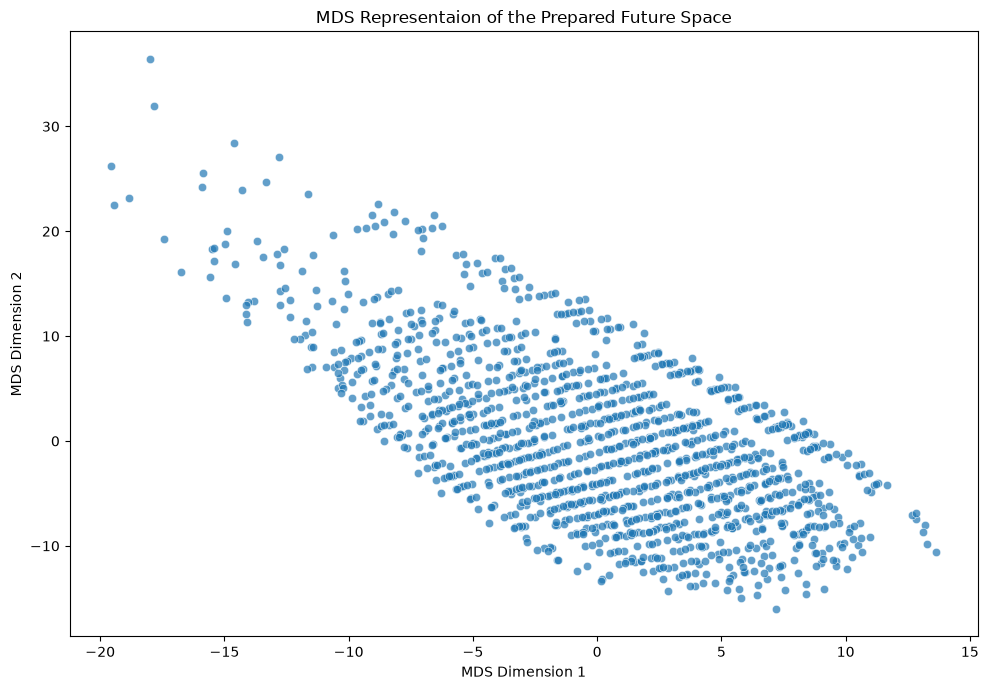

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=X_mds,
    x="MDS1",
    y="MDS2",
    alpha=0.7,
    ax=ax,
)

ax.set(
    title="MDS Representaion of the Prepared Future Space",
    xlabel="MDS Dimension 1",
    ylabel="MDS Dimension 2",
)

plt.tight_layout()
plt.show()

## Locally Linear Embedding

Locally Linear Embedding (LLE) is considered as an additional nonlinear
dimensionality-reduction method.

LLE depends on local neighbourhood relationships. Its usefulness therefore
depends on whether the prepared feature space contains a meaningful
lower-dimensional manifold structure.

It will not be treated as a required representation merely because it is
available. Its use should be justified by the analytical characteristics and
the objectives of the dimensionality-reduction stage.

## Dimensionality-Reduction Summary

The dimensionality-reduction stage produces two representations for comparison:

- PCA: a variance-preserving linear representation;
- MDS: a distance-preserving complementary representation.

The PCA representation is the primary candidate for the subsequent clustering
experiments because its dimensionality and explained variance can be quantified
directly.

MDS provides a complementary representation that can be examined alongside
PCA. LLE is retained only if its methodological justification is established.

In [25]:
reduction_summary = pd.DataFrame(
    {
        "method": [
            "original",
            "PCA",
            "MDS",
        ],
        "dimensions": [
            X_encoded.shape[1],
            X_pca.shape[1],
            X_mds.shape[1],
        ],
    }
)

reduction_summary

,method,dimensions
0,original,495
1,PCA,44
2,MDS,2


## Conclusion

The prepared analytical feature matrix from Notebook 02 was successfully
loaded without additional cleaning or feature engineering.

PCA was evaluated as the primary dimensionality-reduction method through its
explained-variance structure and component loadings. A reduced PCA
representation was generated for subsequent clustering experiments.

MDS was evaluated as a complementary distance-based representation. LLE was
considered separately and will only be retained if its use is justified by the
structure of the prepared data and the methodological guidance.

The dimensionality-reduction results will inform the clustering experiments in
Notebook 04. Final clustering performance will be evaluated using the
evaluation criteria established for the project rather than selecting a
representation from dimensionality-reduction diagnostics alone.